In [ ]:
"""
Cardiac Arrhythmia Classification — Deep Learning Pipeline
===========================================================
Architecture : 1-D CNN + Squeeze-and-Excitation + Bidirectional GRU
Training     : 5-Fold Stratified Cross-Validation with Focal Loss
Inference    : Soft-Voting Ensemble + Per-Class Threshold Tuning
"""

# ── Standard library ──────────────────────────────────────────────────────────
import os
import json
import pickle

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models, backend as K
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from imblearn.over_sampling import RandomOverSampler

# Google Colab — comment out when running locally
from google.colab import drive
drive.mount("/content/drive")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
TRAIN_DATA_PATH  = "/content/drive/MyDrive/Proyecto_DEEP_LEARNING/training_set_500.h5"
TEST_DATA_PATH   = "/content/drive/MyDrive/Proyecto_DEEP_LEARNING/test_without_labels_200.h5"
CHECKPOINT_DIR   = "/content/drive/MyDrive/Proyecto_DEEP_LEARNING/checkpointssmg3gru_1/"
OUTPUT_PRED_PATH = "/content/drive/MyDrive/Proyecto_DEEP_LEARNING/final_predictions_1.npy"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

INPUT_SHAPE         = (2049, 1)
EMBED_DIM           = 64
NUM_CLASSES         = 3
CLASS_NAMES         = ["Normal", "Arrhythmia", "Noise"]
N_FOLDS             = 5
BATCH_SIZE          = 32
LEARNING_RATE       = 0.001
MAX_EPOCHS          = 40
LR_PATIENCE         = 3
EARLY_STOP_PATIENCE = 50


Mounted at /content/drive


In [ ]:


# ─────────────────────────────────────────────────────────────────────────────
# DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────
print("Loading data from HDF5 files …")

with h5py.File(TRAIN_DATA_PATH, "r") as h5_file:
    X_train        = np.array(h5_file["data"],    dtype=np.float32)
    y_train        = np.squeeze(np.array(h5_file["labels"],  dtype=np.int32))
    patient_groups = np.squeeze(np.array(h5_file["patient"], dtype=np.int32))

with h5py.File(TEST_DATA_PATH, "r") as h5_file:
    X_test_raw = np.array(h5_file["data"], dtype=np.float32)

print(f"Dataset loaded — train: {X_train.shape[0]} samples | test: {X_test_raw.shape[0]} samples")


# ─────────────────────────────────────────────────────────────────────────────
# PREPROCESSING
# ─────────────────────────────────────────────────────────────────────────────
def z_score_normalize(X: np.ndarray) -> np.ndarray:
    """Per-sample Z-score normalisation along the time axis."""
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1,  keepdims=True) + 1e-8
    return (X - mean) / std


X_train    = z_score_normalize(X_train)
X_test_raw = z_score_normalize(X_test_raw)

# Add channel dimension → (N, 2049, 1)
X_train_3d = np.expand_dims(X_train, axis=-1) if X_train.ndim == 2 else X_train
X_test_3d  = np.expand_dims(X_test_raw, axis=-1) if X_test_raw.ndim == 2 else X_test_raw

# One-hot labels
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=NUM_CLASSES)



Loading data from HDF5 files …
Dataset loaded — train: 116953 samples | test: 46943 samples


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# MODEL ARCHITECTURE
# ─────────────────────────────────────────────────────────────────────────────
def squeeze_excitation_block(
    input_tensor: tf.Tensor,
    reduction_ratio: int = 8,
) -> tf.Tensor:
    """
    1-D Squeeze-and-Excitation attention block.
    Input shape : (Batch, Length, Channels)
    Output shape: (Batch, Length, Channels)
    """
    num_channels = input_tensor.shape[-1]

    # Squeeze: global context descriptor
    context_vector = layers.GlobalAveragePooling1D()(input_tensor)

    # Excitation: two-layer bottleneck MLP
    excitation = layers.Dense(
        num_channels // reduction_ratio,
        activation="relu",
        kernel_initializer="he_normal",
    )(context_vector)
    excitation = layers.Dense(num_channels, activation="sigmoid")(excitation)
    excitation = layers.Reshape((1, num_channels))(excitation)

    # Feature recalibration
    recalibrated = layers.Multiply()([input_tensor, excitation])
    return recalibrated


def build_ecg_classifier(
    input_shape: tuple = (2049, 1),
    num_classes: int = 3,
) -> tf.keras.Model:
    """
    1-D CNN with SE-Attention and Bidirectional GRU head.

    Stage 1 : Conv1D(32,  k=7) → BN → ReLU → MaxPool(2) → Dropout(0.2)
    Stage 2 : Conv1D(64,  k=5) → BN → ReLU → MaxPool(2) → Dropout(0.2)
    Stage 3 : Conv1D(128, k=3) → BN → ReLU → MaxPool(2) → Dropout(0.2)
    Stage 4 : Conv1D(256, k=3) → BN → ReLU → SE-Block
    Head    : BiGRU(64) → Dense(128) → Dropout(0.5) → Softmax(num_classes)
    """
    inputs = layers.Input(shape=input_shape)

    # Stage 1
    x = layers.Conv1D(32, kernel_size=7, padding="same", kernel_initializer="he_normal")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    # Stage 2
    x = layers.Conv1D(64, kernel_size=5, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    # Stage 3
    x = layers.Conv1D(128, kernel_size=3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    # Stage 4
    x = layers.Conv1D(256, kernel_size=3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # Attention module
    x = squeeze_excitation_block(x, reduction_ratio=8)

    # Sequence encoder
    x = layers.Bidirectional(layers.GRU(64, return_sequences=False))(x)

    # Classification head
    x = layers.Dense(128, activation="relu", kernel_initializer="he_normal")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs=inputs, outputs=outputs, name="ECGNet_SE_BiGRU")


# ─────────────────────────────────────────────────────────────────────────────
# CUSTOM LOSS — FOCAL LOSS WITH LABEL SMOOTHING
# ─────────────────────────────────────────────────────────────────────────────
def focal_loss(gamma: float = 3.0, alpha: float = 1.0, label_smoothing: float = 0.05):
    """
    Multiclass Focal Loss with label smoothing.

    Parameters
    ----------
    gamma          : focusing exponent (higher → harder examples weighted more)
    alpha          : scaling factor
    label_smoothing: soft label coefficient
    """
    def focal_loss_fixed(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
        y_true      = tf.cast(y_true, tf.float32)
        num_classes = tf.cast(tf.shape(y_true)[-1], tf.float32)
        y_true      = y_true * (1.0 - label_smoothing) + (label_smoothing / num_classes)
        y_pred      = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight  = alpha * tf.math.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(focal_weight * cross_entropy, axis=-1)

    return focal_loss_fixed


# ─────────────────────────────────────────────────────────────────────────────
# CUSTOM CALLBACKS
# ─────────────────────────────────────────────────────────────────────────────
class TrainingStateCheckpoint(tf.keras.callbacks.Callback):
    """
    Persists model weights and optimiser state at each epoch end
    to allow seamless training resumption after interruptions.
    """

    def __init__(self, checkpoint_dir: str, fold_index: int):
        super().__init__()
        self.checkpoint_dir = checkpoint_dir
        self.fold_index     = fold_index
        self.state_path     = os.path.join(checkpoint_dir, f"training_state_fold_{fold_index}.pkl")

    def on_epoch_end(self, epoch: int, logs: dict = None):
        weights_path = os.path.join(
            self.checkpoint_dir, f"resume_weights_fold_{self.fold_index}.weights.h5"
        )
        self.model.save_weights(weights_path)

        state = {
            "epoch": epoch + 1,
            "fold":  self.fold_index,
            "logs":  logs,
            "lr":    float(self.model.optimizer.learning_rate),
        }
        with open(self.state_path, "wb") as fp:
            pickle.dump(state, fp)


class F1MacroCallback(tf.keras.callbacks.Callback):
    """
    Computes and logs val_f1_macro at the end of each epoch.
    Injecting it into `logs` makes it available to all other callbacks
    (e.g. ModelCheckpoint, ReduceLROnPlateau) and to history.history.

    Parameters
    ----------
    val_data : tuple (X_val, y_val_onehot)
    """

    def __init__(self, val_data: tuple):
        super().__init__()
        self.X_val = val_data[0]
        self.y_val = val_data[1]           # one-hot

    def on_epoch_end(self, epoch: int, logs: dict = None):
        val_probs  = self.model.predict(self.X_val, verbose=0)
        val_preds  = np.argmax(val_probs,  axis=-1)
        val_true   = np.argmax(self.y_val, axis=-1)
        score      = f1_score(val_true, val_preds, average="macro", zero_division=0)
        logs["val_f1_macro"] = score


class HistoryPersistenceCallback(tf.keras.callbacks.Callback):
    """
    Appends epoch metrics to a JSON file after every epoch so that
    training history survives Colab disconnections and multi-account runs.

    The JSON stores lists for every key in `logs` (loss, accuracy,
    val_loss, val_accuracy, val_f1_macro, …).  On resumption the new
    epochs are appended rather than overwriting previous data.

    Parameters
    ----------
    history_path : full path to the target .json file
    """

    def __init__(self, history_path: str):
        super().__init__()
        self.history_path = history_path

    def on_epoch_end(self, epoch: int, logs: dict = None):
        logs = logs or {}

        # Load existing data if the file already exists (resumed run)
        if os.path.exists(self.history_path):
            with open(self.history_path, "r") as fp:
                stored = json.load(fp)
        else:
            stored = {}

        # Append current epoch values
        for key, value in logs.items():
            stored.setdefault(key, []).append(float(value))

        with open(self.history_path, "w") as fp:
            json.dump(stored, fp, indent=2)




Starting 5-Fold cross-validation with Focal Loss …


────────────────────────────────────────────────────────────
  FOLD 1 / 5
────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  Resuming from epoch 40
731/731 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step

────────────────────────────────────────────────────────────
  FOLD 2 / 5
────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  Resuming from epoch 40
731/731 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step

────────────────────────────────────────────────────────────
  FOLD 3 / 5
────────────────────────────────────────────────────────────


...

  Resuming from epoch 40
731/731 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step

────────────────────────────────────────────────────────────
  FOLD 4 / 5
────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  Resuming from epoch 40
731/731 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step

────────────────────────────────────────────────────────────
  FOLD 5 / 5
────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  Resuming from epoch 40
731/731 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step


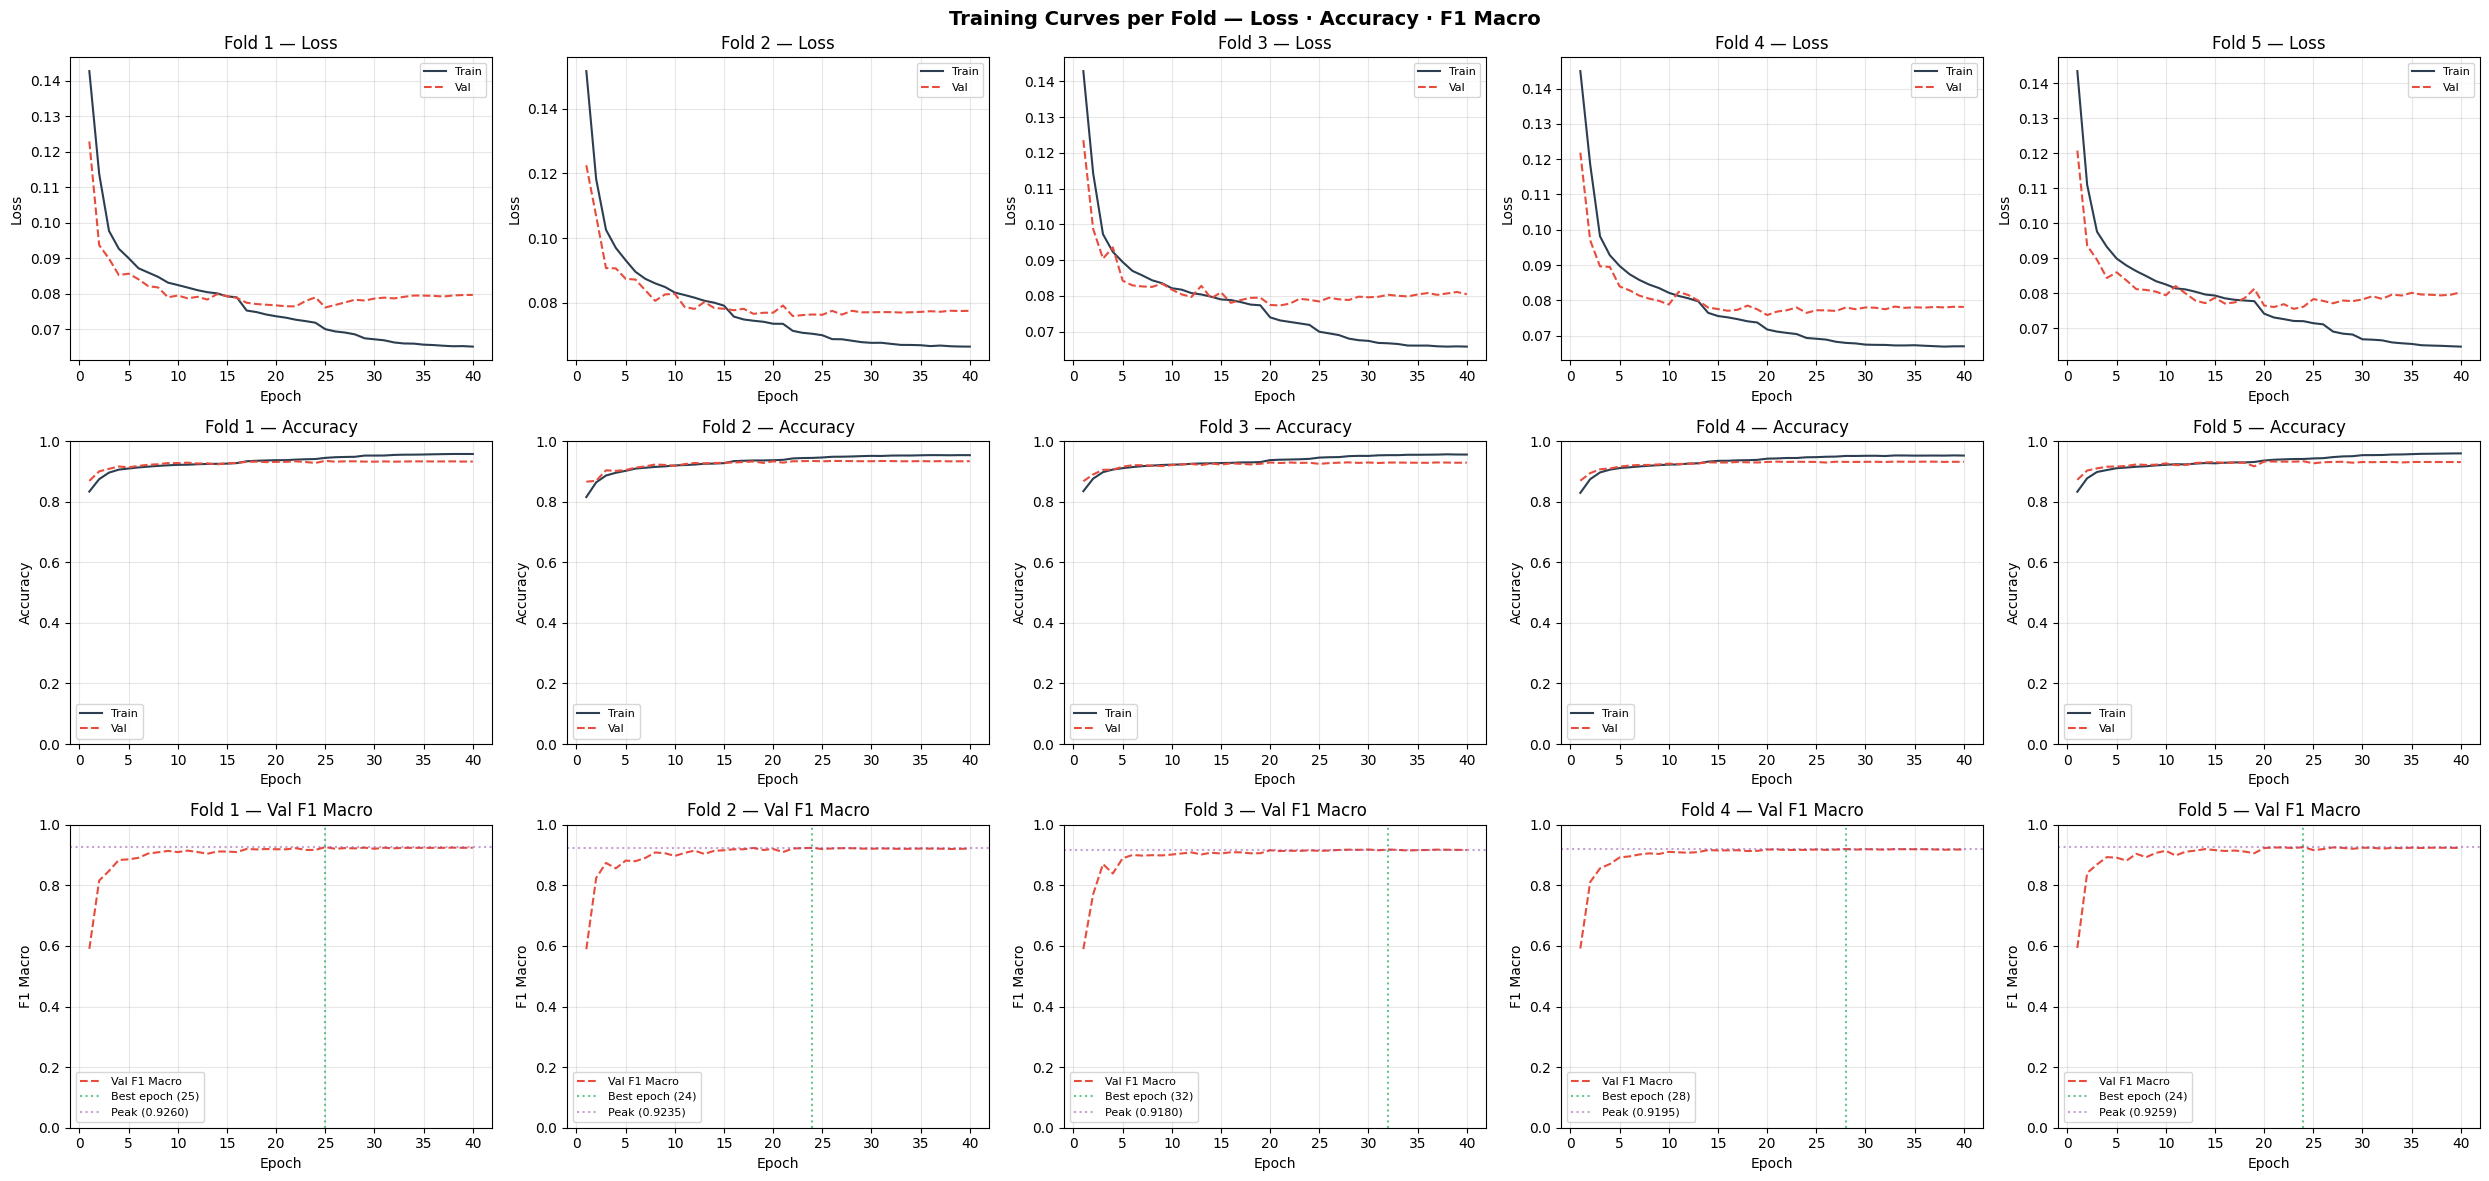

Training curves saved → /content/drive/MyDrive/Proyecto_DEEP_LEARNING/checkpointssmg3gru_1/training_curves.png


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# TRAINING — STRATIFIED K-FOLD CROSS-VALIDATION
# ─────────────────────────────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
oof_probabilities = np.zeros((X_train.shape[0], NUM_CLASSES))

print(f"\nStarting {N_FOLDS}-Fold cross-validation with Focal Loss …\n")

for fold_idx, (train_indices, val_indices) in enumerate(skf.split(X_train, y_train)):
    print(f"\n{'─'*60}")
    print(f"  FOLD {fold_idx + 1} / {N_FOLDS}")
    print(f"{'─'*60}")

    X_fold_train, y_fold_train = X_train_3d[train_indices], y_train_onehot[train_indices]
    X_fold_val,   y_fold_val   = X_train_3d[val_indices],   y_train_onehot[val_indices]

    # ── Build and compile model ───────────────────────────────────────────────
    model = build_ecg_classifier(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)
    optimizer = tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=0.01)
    model.compile(
        optimizer=optimizer,
        loss=focal_loss(),
        metrics=["accuracy"],
    )

    # ── Resume from checkpoint if available ──────────────────────────────────
    state_path   = os.path.join(CHECKPOINT_DIR, f"training_state_fold_{fold_idx + 1}.pkl")
    weights_path = os.path.join(CHECKPOINT_DIR, f"resume_weights_fold_{fold_idx + 1}.weights.h5")
    start_epoch  = 0

    if os.path.exists(state_path) and os.path.exists(weights_path):
        with open(state_path, "rb") as fp:
            saved_state = pickle.load(fp)
        start_epoch = saved_state["epoch"]
        model.load_weights(weights_path)
        model.optimizer.learning_rate.assign(saved_state["lr"])
        print(f"  Resuming from epoch {start_epoch}")
    else:
        print("  Starting from scratch")

    # ── Callbacks ─────────────────────────────────────────────────────────────
    best_model_path = os.path.join(CHECKPOINT_DIR, f"best_model_fold_{fold_idx + 1}.keras")
    history_path    = os.path.join(CHECKPOINT_DIR, f"history_fold_{fold_idx + 1}.json")

    callbacks = [
        F1MacroCallback(val_data=(X_fold_val, y_fold_val)),   # must be first -> injects val_f1_macro into logs
        ModelCheckpoint(
            filepath=best_model_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=LR_PATIENCE,
            verbose=1,
            min_lr=1e-6,
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOP_PATIENCE,
            verbose=1,
            restore_best_weights=True,
        ),
        TrainingStateCheckpoint(checkpoint_dir=CHECKPOINT_DIR, fold_index=fold_idx + 1),
        HistoryPersistenceCallback(history_path=history_path),  # must be last -> all metrics already in logs
    ]

    # ── Class-balance oversampling ────────────────────────────────────────────
    oversampler = RandomOverSampler(random_state=42)
    X_flat      = X_fold_train.reshape(X_fold_train.shape[0], -1)
    X_resampled, y_resampled_int = oversampler.fit_resample(
        X_flat, np.argmax(y_fold_train, axis=-1)
    )
    X_resampled = X_resampled.reshape(-1, INPUT_SHAPE[0], 1)
    y_resampled = tf.keras.utils.to_categorical(y_resampled_int, num_classes=NUM_CLASSES)

    # ── Fit ───────────────────────────────────────────────────────────────────
    model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=MAX_EPOCHS,
        initial_epoch=start_epoch,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    # ── OOF predictions ───────────────────────────────────────────────────────
    best_model = models.load_model(
        best_model_path,
        custom_objects={"focal_loss_fixed": focal_loss()},
    )
    oof_probabilities[val_indices] = best_model.predict(X_fold_val, batch_size=BATCH_SIZE)


# ─────────────────────────────────────────────────────────────────────────────
# TRAINING CURVES — LOSS, ACCURACY AND F1 PER FOLD
# ─────────────────────────────────────────────────────────────────────────────
def plot_training_curves(checkpoint_dir: str, n_folds: int) -> None:
    """
    Loads the persisted JSON history for every fold and renders a
    3-row × N_FOLDS grid showing Loss, Accuracy and F1 Macro curves.
    The figure is saved to `checkpoint_dir/training_curves.png`.
    """
    fig, axes = plt.subplots(3, n_folds, figsize=(5 * n_folds, 12))
    fig.suptitle(
        "Training Curves per Fold — Loss · Accuracy · F1 Macro",
        fontsize=14,
        fontweight="bold",
    )

    row_titles = ["Loss", "Accuracy", "F1 Macro (val)"]
    colors     = {"train": "#2c3e50", "val": "#e74c3c"}

    for fold_idx in range(n_folds):
        history_path = os.path.join(checkpoint_dir, f"history_fold_{fold_idx + 1}.json")

        if not os.path.exists(history_path):
            for row in range(3):
                axes[row, fold_idx].set_visible(False)
            continue

        with open(history_path, "r") as fp:
            hist = json.load(fp)

        epochs = range(1, len(hist.get("loss", [])) + 1)

        # ── Row 0: Loss ───────────────────────────────────────────────────────
        ax = axes[0, fold_idx]
        ax.plot(epochs, hist.get("loss",     []), color=colors["train"], label="Train")
        ax.plot(epochs, hist.get("val_loss", []), color=colors["val"],   label="Val",   linestyle="--")
        ax.set_title(f"Fold {fold_idx + 1} — Loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # ── Row 1: Accuracy ───────────────────────────────────────────────────
        ax = axes[1, fold_idx]
        ax.plot(epochs, hist.get("accuracy",     []), color=colors["train"], label="Train")
        ax.plot(epochs, hist.get("val_accuracy", []), color=colors["val"],   label="Val",   linestyle="--")
        ax.set_title(f"Fold {fold_idx + 1} — Accuracy")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.set_ylim([0, 1.0])
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # ── Row 2: F1 Macro (validation only — no train F1 tracked) ──────────
        ax = axes[2, fold_idx]
        val_f1 = hist.get("val_f1_macro", [])
        if val_f1:
            ax.plot(epochs, val_f1, color=colors["val"], label="Val F1 Macro", linestyle="--")
            best_epoch = int(np.argmax(val_f1)) + 1
            ax.axvline(best_epoch, color="#27ae60", linestyle=":", alpha=0.7,
                       label=f"Best epoch ({best_epoch})")
            ax.axhline(max(val_f1), color="#8e44ad", linestyle=":", alpha=0.5,
                       label=f"Peak ({max(val_f1):.4f})")
        ax.set_title(f"Fold {fold_idx + 1} — Val F1 Macro")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("F1 Macro")
        ax.set_ylim([0, 1.0])
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(checkpoint_dir, "training_curves.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Training curves saved → {save_path}")


plot_training_curves(CHECKPOINT_DIR, N_FOLDS)



In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION — RELOAD BEST CHECKPOINTS AND COMPUTE METRICS
# ─────────────────────────────────────────────────────────────────────────────
print("\n\nReloading best checkpoints for evaluation …")

fold_macro_f1_scores = []
fold_per_class_f1    = []
val_probabilities    = []
val_true_labels      = []
test_fold_probs      = []

for fold_idx, (train_indices, val_indices) in enumerate(skf.split(X_train, y_train)):
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"best_model_fold_{fold_idx + 1}.keras")

    if not os.path.exists(checkpoint_path):
        print(f"  Checkpoint for fold {fold_idx + 1} not found — skipping.")
        continue

    eval_model = models.load_model(
        checkpoint_path,
        custom_objects={"focal_loss_fixed": focal_loss(gamma=3.0, alpha=1.0, label_smoothing=0.05)},
    )

    X_fold_val      = X_train_3d[val_indices]
    y_fold_val_true = y_train[val_indices]

    val_probs = eval_model.predict(X_fold_val, batch_size=BATCH_SIZE, verbose=0)
    val_preds = np.argmax(val_probs, axis=-1)

    macro_f1     = f1_score(y_fold_val_true, val_preds, average="macro")
    per_class_f1 = f1_score(y_fold_val_true, val_preds, average=None)

    fold_macro_f1_scores.append(macro_f1)
    fold_per_class_f1.append(per_class_f1)
    val_true_labels.append(y_fold_val_true)
    val_probabilities.append(val_probs)

    print(f"\n{'='*50}")
    print(f"  Fold {fold_idx + 1} — Validation Results")
    print(f"{'='*50}")
    print(f"  F1 Macro : {macro_f1:.4f}")
    print(classification_report(y_fold_val_true, val_preds, target_names=CLASS_NAMES))

    test_fold_probs.append(eval_model.predict(X_test_3d, batch_size=BATCH_SIZE, verbose=0))


# ─────────────────────────────────────────────────────────────────────────────
# FINE-TUNING — LAST-LAYER ADAPTATION
# ─────────────────────────────────────────────────────────────────────────────
print("\n\nFine-tuning best models (last 3 layers unfrozen) …")

for fold_idx, (train_indices, val_indices) in enumerate(skf.split(X_train, y_train)):
    base_ckpt      = os.path.join(CHECKPOINT_DIR, f"best_model_fold_{fold_idx + 1}.keras")
    finetuned_ckpt = os.path.join(CHECKPOINT_DIR, f"best_model_fold_{fold_idx + 1}_finetuned.keras")
    ft_history_path = os.path.join(CHECKPOINT_DIR, f"history_fold_{fold_idx + 1}_finetuned.json")

    if not os.path.exists(base_ckpt):
        print(f"  Base checkpoint for fold {fold_idx + 1} not found — skipping.")
        continue

    pretrained_model = models.load_model(
        base_ckpt,
        custom_objects={"focal_loss_fixed": focal_loss(gamma=3.0, alpha=1.0, label_smoothing=0.05)},
    )

    # Freeze all layers except the last three
    for layer in pretrained_model.layers[:-3]:
        layer.trainable = False

    pretrained_model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=0.01),
        loss=focal_loss(gamma=3.0, alpha=1.0, label_smoothing=0.05),
        metrics=["accuracy"],
    )

    X_fold_train, y_fold_train = X_train_3d[train_indices], y_train_onehot[train_indices]
    X_fold_val,   y_fold_val   = X_train_3d[val_indices],   y_train_onehot[val_indices]

    pretrained_model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=15,
        batch_size=BATCH_SIZE,
        callbacks=[
            F1MacroCallback(val_data=(X_fold_val, y_fold_val)),
            ModelCheckpoint(finetuned_ckpt, monitor="val_loss", save_best_only=True, verbose=1),
            EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
            HistoryPersistenceCallback(history_path=ft_history_path),
        ],
        verbose=1,
    )
    print(f"  Fold {fold_idx + 1} fine-tuned model saved: {finetuned_ckpt}")


# ─────────────────────────────────────────────────────────────────────────────
# ENSEMBLE EVALUATION — OOF METRICS WITH FINE-TUNED MODELS
# ─────────────────────────────────────────────────────────────────────────────
oof_prob_matrix     = np.zeros((X_train.shape[0], NUM_CLASSES), dtype=np.float32)
oof_true_labels     = np.zeros(X_train.shape[0], dtype=np.int32)
ensemble_test_probs = []

fold_f1_scores     = []
fold_class_f1s     = []
fold_conf_matrices = []

for fold_idx, (train_indices, val_indices) in enumerate(skf.split(X_train, y_train)):
    finetuned_ckpt     = os.path.join(CHECKPOINT_DIR, f"best_model_fold_{fold_idx + 1}_finetuned.keras")
    base_ckpt          = os.path.join(CHECKPOINT_DIR, f"best_model_fold_{fold_idx + 1}.keras")
    checkpoint_to_load = finetuned_ckpt if os.path.exists(finetuned_ckpt) else base_ckpt

    if not os.path.exists(checkpoint_to_load):
        print(f"  No checkpoint found for fold {fold_idx + 1} — skipping.")
        continue

    model = models.load_model(
        checkpoint_to_load,
        custom_objects={"focal_loss_fixed": focal_loss(gamma=3.0, alpha=1.0, label_smoothing=0.05)},
    )

    X_fold_val      = X_train_3d[val_indices]
    y_fold_val_true = y_train[val_indices]

    fold_val_probs = model.predict(X_fold_val, batch_size=BATCH_SIZE, verbose=0)
    fold_val_preds = np.argmax(fold_val_probs, axis=-1)

    # Accumulate OOF
    oof_prob_matrix[val_indices] = fold_val_probs
    oof_true_labels[val_indices] = y_fold_val_true

    macro_f1    = f1_score(y_fold_val_true, fold_val_preds, average="macro")
    class_f1s   = f1_score(y_fold_val_true, fold_val_preds, average=None)
    conf_matrix = confusion_matrix(y_fold_val_true, fold_val_preds)

    fold_f1_scores.append(macro_f1)
    fold_class_f1s.append(class_f1s)
    fold_conf_matrices.append(conf_matrix)

    print(f"\n  Fold {fold_idx + 1} — F1 Macro: {macro_f1:.4f}")
    print(classification_report(y_fold_val_true, fold_val_preds, target_names=CLASS_NAMES))

    ensemble_test_probs.append(model.predict(X_test_3d, batch_size=BATCH_SIZE, verbose=0))

# Global OOF metrics
oof_predictions = np.argmax(oof_prob_matrix, axis=-1)
global_macro_f1 = f1_score(oof_true_labels, oof_predictions, average="macro")
global_conf_mat = confusion_matrix(oof_true_labels, oof_predictions)

print(f"\n{'='*60}")
print("GLOBAL OOF METRICS")
print(f"{'='*60}")
print(f"  F1 Macro (global): {global_macro_f1:.4f}")
print(classification_report(oof_true_labels, oof_predictions, target_names=CLASS_NAMES))






Reloading best checkpoints for evaluation …

  Fold 1 — Validation Results
  F1 Macro : 0.9260
              precision    recall  f1-score   support

      Normal       0.94      0.95      0.95     13040
  Arrhythmia       0.91      0.91      0.91       951
       Noise       0.92      0.92      0.92      9400

    accuracy                           0.93     23391
   macro avg       0.93      0.92      0.93     23391
weighted avg       0.93      0.93      0.93     23391


  Fold 2 — Validation Results
  F1 Macro : 0.9200
              precision    recall  f1-score   support

      Normal       0.94      0.95      0.95     13039
  Arrhythmia       0.90      0.89      0.89       951
       Noise       0.92      0.92      0.92      9401

    accuracy                           0.93     23391
   macro avg       0.92      0.92      0.92     23391
weighted avg       0.93      0.93      0.93     23391


  Fold 3 — Validation Results
  F1 Macro : 0.9129
              precision    recall  f1-s


Searching for optimal per-class decision thresholds …
  Optimal thresholds:
    Normal     (class 0): 0.500
    Arrhythmia (class 1): 0.457
    Noise      (class 2): 0.414
  OOF F1 Macro with threshold tuning: 0.9218

Final predictions saved : /content/drive/MyDrive/Proyecto_DEEP_LEARNING/final_predictions_1.npy
  Shape  : (46943, 3)  (samples × 3)

  Test-set class distribution:
    Normal: 27060 samples
    Arrhythmia: 446 samples
    Noise: 19437 samples


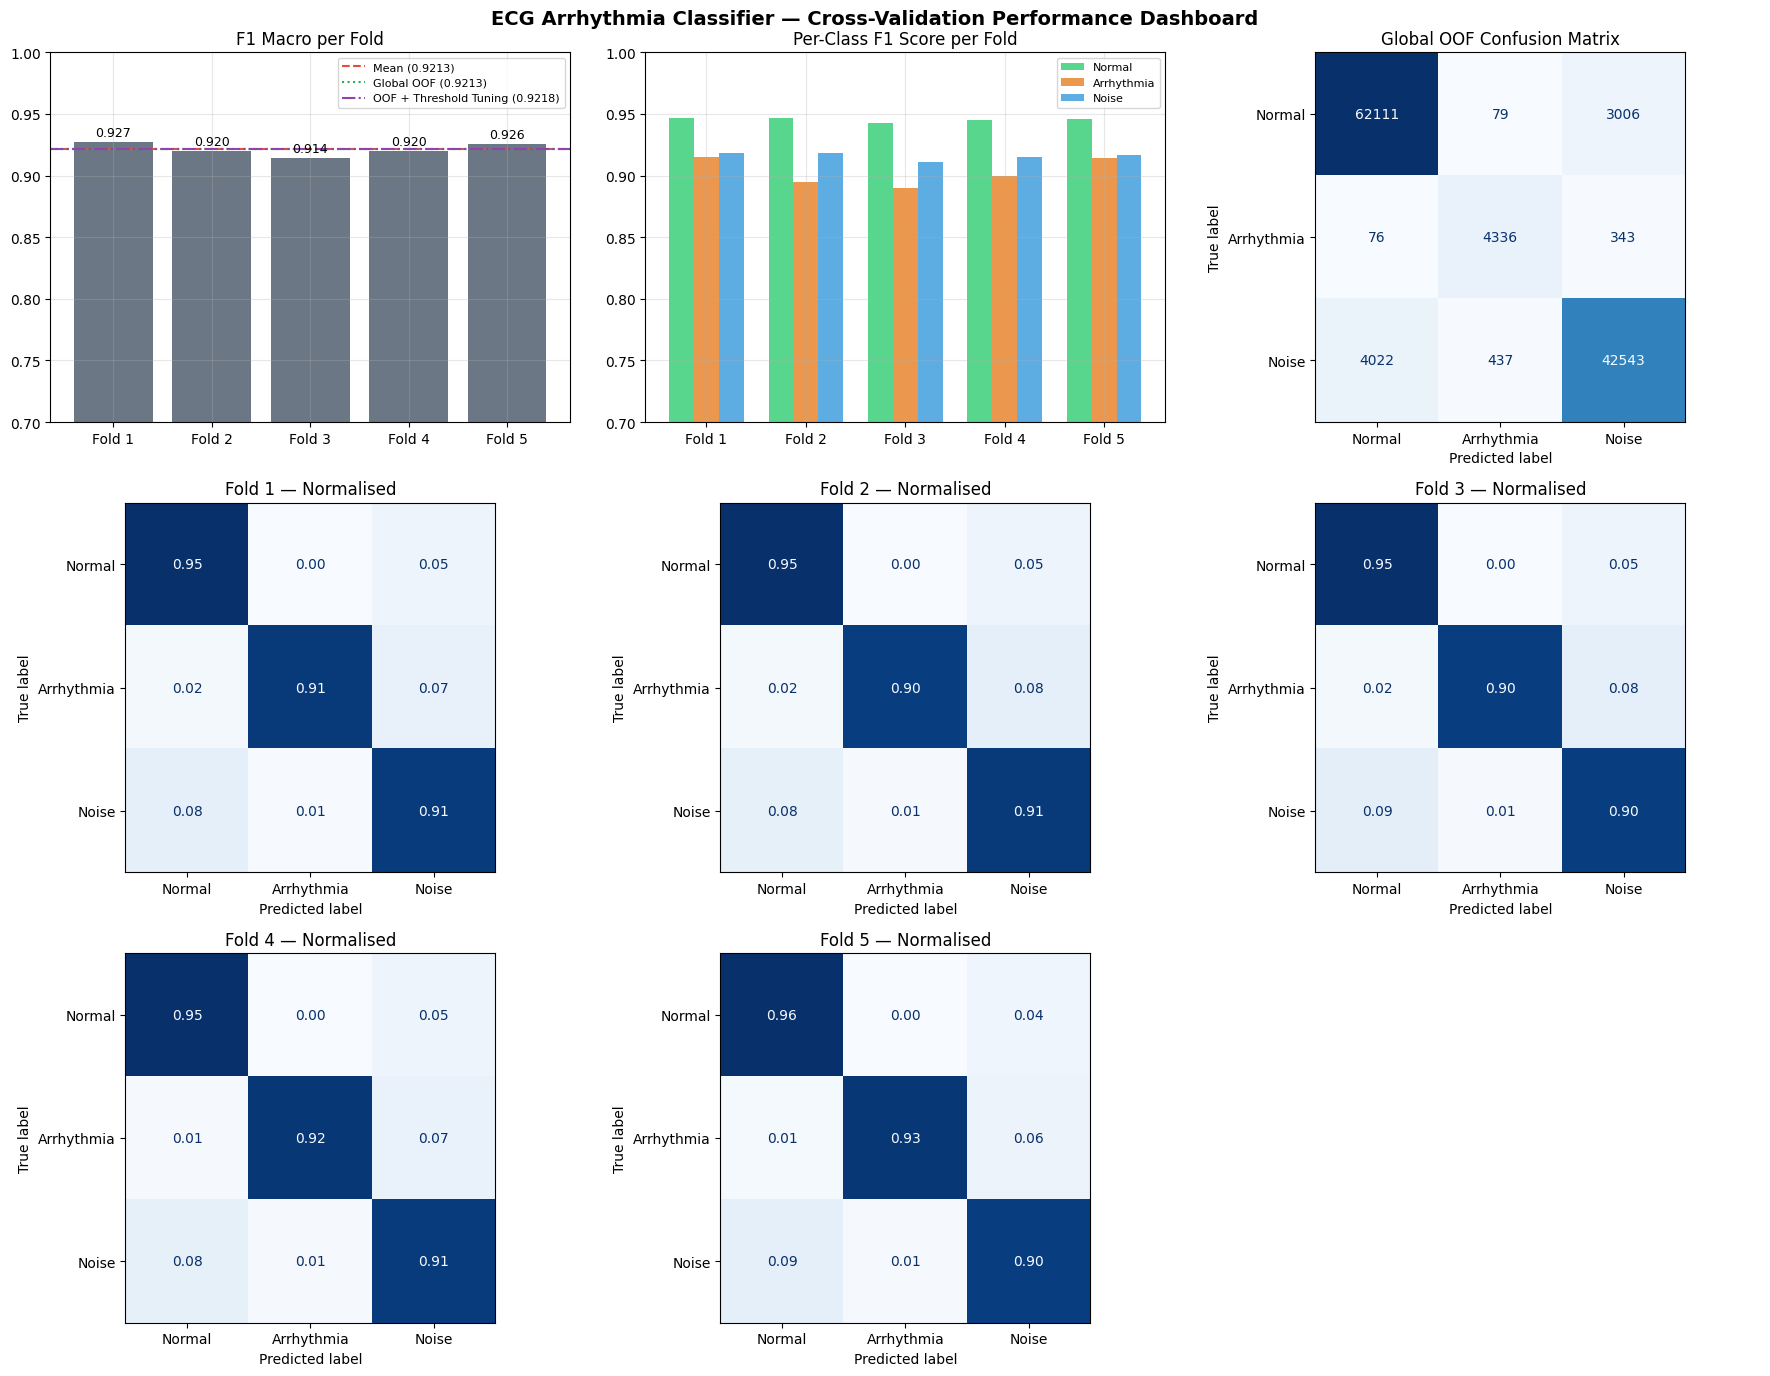


Dashboard saved: /content/drive/MyDrive/Proyecto_DEEP_LEARNING/checkpointssmg3gru_1/performance_dashboard.png


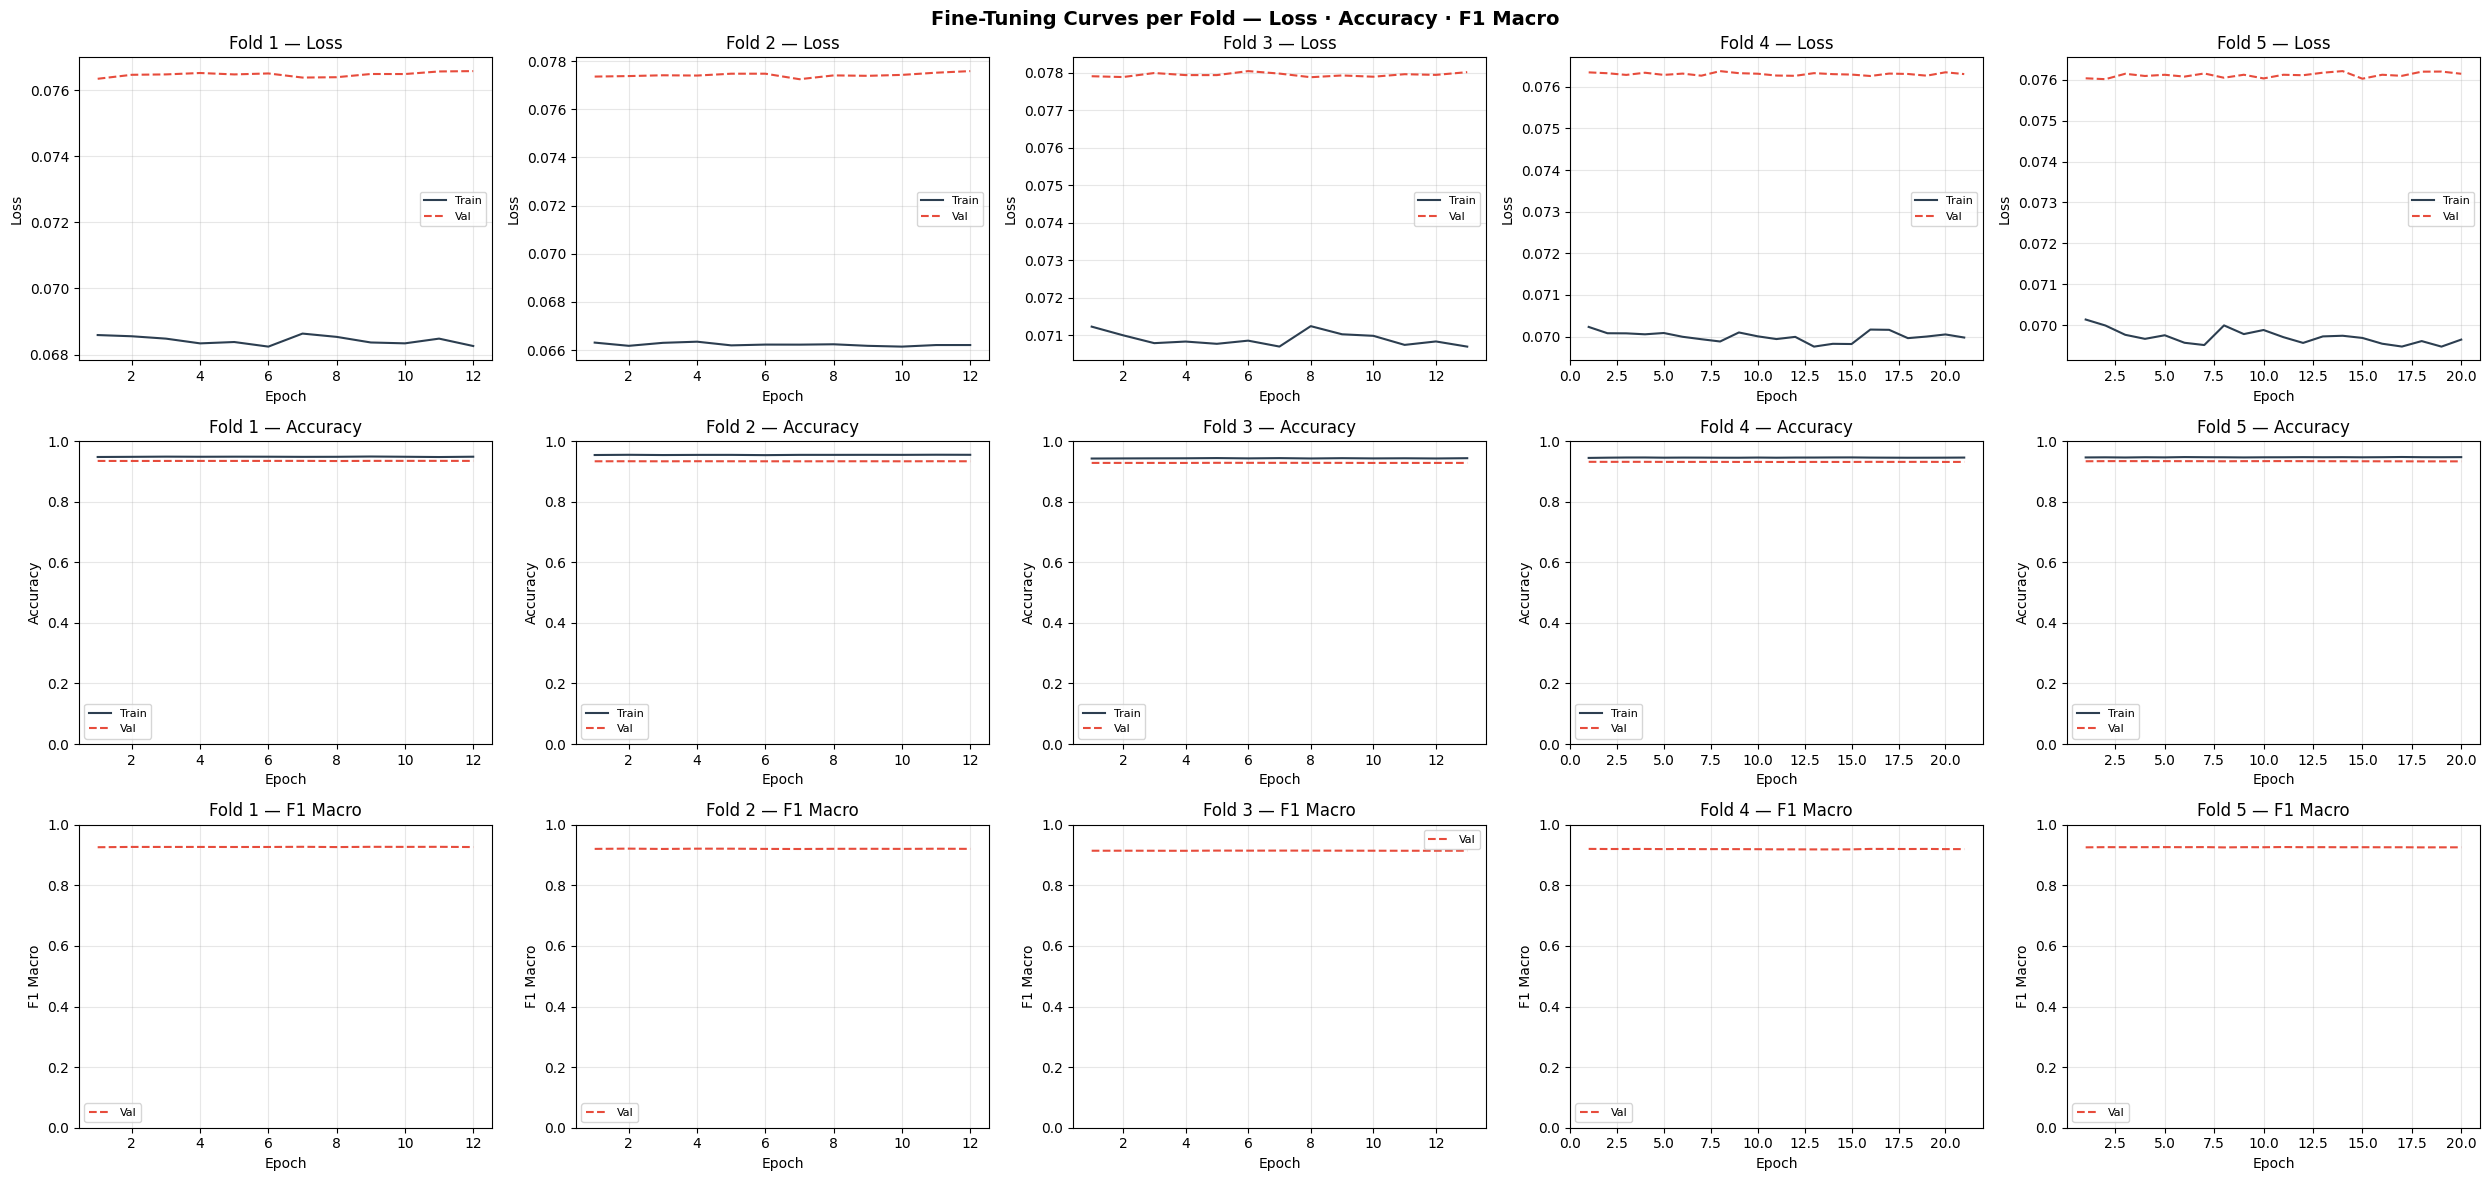

Fine-tuning curves saved : /content/drive/MyDrive/Proyecto_DEEP_LEARNING/checkpointssmg3gru_1/finetuning_curves.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# THRESHOLD TUNING — GRID SEARCH OVER PER-CLASS DECISION BOUNDARIES
# ─────────────────────────────────────────────────────────────────────────────
print("\nSearching for optimal per-class decision thresholds …")

mean_test_probs = np.mean(np.array(ensemble_test_probs), axis=0)
threshold_grid  = np.linspace(0.20, 0.80, 15)
best_macro_f1   = 0.0
best_thresholds = (0.33, 0.33, 0.33)

prob_class0 = oof_prob_matrix[:, 0]
prob_class1 = oof_prob_matrix[:, 1]
prob_class2 = oof_prob_matrix[:, 2]

for th0 in threshold_grid:
    for th1 in threshold_grid:
        for th2 in threshold_grid:
            above_th0 = prob_class0 >= th0
            above_th1 = prob_class1 >= th1
            above_th2 = prob_class2 >= th2

            candidate_preds = np.argmax(oof_prob_matrix, axis=-1).copy()
            any_above       = above_th0 | above_th1 | above_th2

            masked_probs = oof_prob_matrix.copy()
            masked_probs[~above_th0, 0] = -1
            masked_probs[~above_th1, 1] = -1
            masked_probs[~above_th2, 2] = -1
            candidate_preds[any_above] = np.argmax(masked_probs[any_above], axis=-1)

            candidate_f1 = f1_score(oof_true_labels, candidate_preds, average="macro")
            if candidate_f1 > best_macro_f1:
                best_macro_f1   = candidate_f1
                best_thresholds = (th0, th1, th2)

th0_opt, th1_opt, th2_opt = best_thresholds
print(f"  Optimal thresholds:")
print(f"    Normal     (class 0): {th0_opt:.3f}")
print(f"    Arrhythmia (class 1): {th1_opt:.3f}")
print(f"    Noise      (class 2): {th2_opt:.3f}")
print(f"  OOF F1 Macro with threshold tuning: {best_macro_f1:.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# FINAL INFERENCE — SOFT-VOTING ENSEMBLE + THRESHOLD DECODING
# ─────────────────────────────────────────────────────────────────────────────
def apply_threshold_decoding(
    probabilities: np.ndarray,
    thresholds: tuple,
) -> np.ndarray:
    """
    Decode class labels from probability matrix using per-class thresholds.
    For samples where at least one class exceeds its threshold, the winning
    class is the one with the highest probability among those above threshold.
    Falls back to argmax for samples where no threshold is exceeded.
    """
    th0, th1, th2 = thresholds
    above_th0 = probabilities[:, 0] >= th0
    above_th1 = probabilities[:, 1] >= th1
    above_th2 = probabilities[:, 2] >= th2

    decoded_labels = np.argmax(probabilities, axis=-1).copy()
    any_above      = above_th0 | above_th1 | above_th2

    masked_probs = probabilities.copy()
    masked_probs[~above_th0, 0] = -1
    masked_probs[~above_th1, 1] = -1
    masked_probs[~above_th2, 2] = -1
    decoded_labels[any_above] = np.argmax(masked_probs[any_above], axis=-1)

    return decoded_labels


final_test_labels = apply_threshold_decoding(mean_test_probs, best_thresholds)
final_test_onehot = np.eye(NUM_CLASSES, dtype=np.int32)[final_test_labels]

np.save(OUTPUT_PRED_PATH, final_test_onehot)

print(f"\n{'='*60}")
print(f"Final predictions saved : {OUTPUT_PRED_PATH}")
print(f"  Shape  : {final_test_onehot.shape}  (samples × {NUM_CLASSES})")
print("\n  Test-set class distribution:")
for class_idx, class_name in enumerate(CLASS_NAMES):
    count = np.sum(final_test_labels == class_idx)
    print(f"    {class_name}: {count} samples")


# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION — PERFORMANCE DASHBOARD (5 FOLDS)
# ─────────────────────────────────────────────────────────────────────────────
n_evaluated_folds = len(fold_f1_scores)
fold_labels       = [f"Fold {i + 1}" for i in range(n_evaluated_folds)]
fold_class_f1_arr = np.array(fold_class_f1s)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle(
    "ECG Arrhythmia Classifier — Cross-Validation Performance Dashboard",
    fontsize=14,
    fontweight="bold",
)

# Panel 1: F1 Macro per fold
ax   = axes[0, 0]
bars = ax.bar(fold_labels, fold_f1_scores, color="#2c3e50", alpha=0.7)
ax.axhline(np.mean(fold_f1_scores), color="#e74c3c", linestyle="--",
           label=f"Mean ({np.mean(fold_f1_scores):.4f})")
ax.axhline(global_macro_f1, color="#27ae60", linestyle=":",
           label=f"Global OOF ({global_macro_f1:.4f})")
ax.axhline(best_macro_f1, color="#8e44ad", linestyle="-.",
           label=f"OOF + Threshold Tuning ({best_macro_f1:.4f})")
for bar, val in zip(bars, fold_f1_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", fontsize=9)
ax.set_title("F1 Macro per Fold")
ax.set_ylim([0.7, 1.0])
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 2: Per-class F1 per fold
ax           = axes[0, 1]
x_pos        = np.arange(n_evaluated_folds)
bar_width    = 0.25
ax.bar(x_pos - bar_width, fold_class_f1_arr[:, 0], bar_width, label="Normal",     color="#2ecc71", alpha=0.8)
ax.bar(x_pos,             fold_class_f1_arr[:, 1], bar_width, label="Arrhythmia", color="#e67e22", alpha=0.8)
ax.bar(x_pos + bar_width, fold_class_f1_arr[:, 2], bar_width, label="Noise",      color="#3498db", alpha=0.8)
ax.set_title("Per-Class F1 Score per Fold")
ax.set_xticks(x_pos)
ax.set_xticklabels(fold_labels)
ax.set_ylim([0.7, 1.0])
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 3: Global OOF confusion matrix
ax = axes[0, 2]
ConfusionMatrixDisplay(global_conf_mat, display_labels=CLASS_NAMES).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Global OOF Confusion Matrix")

# Panels 4–8: Per-fold normalised confusion matrices
for i in range(len(fold_conf_matrices)):
    row = 1 + (i // 3)
    col = i % 3
    ax  = axes[row, col]
    cm_normalized = fold_conf_matrices[i].astype(float) / fold_conf_matrices[i].sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_normalized, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=False, cmap="Blues", values_format=".2f"
    )
    ax.set_title(f"Fold {i + 1} — Normalised")

# Hide unused subplot
axes[2, 2].axis("off")

plt.tight_layout()
dashboard_path = os.path.join(CHECKPOINT_DIR, "performance_dashboard.png")
plt.savefig(dashboard_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nDashboard saved: {dashboard_path}")

# Plot fine-tuned training curves
plot_training_curves.__doc__  # reuse the same function with finetuned suffix
fig2, axes2 = plt.subplots(3, N_FOLDS, figsize=(5 * N_FOLDS, 12))
fig2.suptitle(
    "Fine-Tuning Curves per Fold — Loss · Accuracy · F1 Macro",
    fontsize=14,
    fontweight="bold",
)
colors = {"train": "#2c3e50", "val": "#e74c3c"}

for fold_idx in range(N_FOLDS):
    ft_history_path = os.path.join(CHECKPOINT_DIR, f"history_fold_{fold_idx + 1}_finetuned.json")

    if not os.path.exists(ft_history_path):
        for row in range(3):
            axes2[row, fold_idx].set_visible(False)
        continue

    with open(ft_history_path, "r") as fp:
        hist = json.load(fp)

    epochs = range(1, len(hist.get("loss", [])) + 1)

    for row, (train_key, val_key, ylabel) in enumerate([
        ("loss",     "val_loss",      "Loss"),
        ("accuracy", "val_accuracy",  "Accuracy"),
        (None,       "val_f1_macro",  "F1 Macro"),
    ]):
        ax = axes2[row, fold_idx]
        if train_key:
            ax.plot(epochs, hist.get(train_key, []), color=colors["train"], label="Train")
        val_data = hist.get(val_key, [])
        ax.plot(epochs, val_data, color=colors["val"], label="Val", linestyle="--")
        if val_data and row in (1, 2):
            ax.set_ylim([0, 1.0])
        ax.set_title(f"Fold {fold_idx + 1} — {ylabel}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.tight_layout()
ft_curves_path = os.path.join(CHECKPOINT_DIR, "finetuning_curves.png")
plt.savefig(ft_curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Fine-tuning curves saved : {ft_curves_path}")